# 216 — Solvent accessibility overlay: do the top HP combos' shared k-mers sit on the exposed face?

**One question:** [212](./212_mhc_domain_localisation.ipynb) located shared k-mers relative to
*domain* boundaries (ARD vs Ig scaffold). This asks the complementary *structural* question: within
whatever domain they land on, do shared k-mers concentrate on the solvent-**exposed** face — the
peptide-binding groove and its surroundings — or on the **buried** hydrophobic core? An encoding
whose signal sits mostly on buried, fold-stabilising residues is detecting "this protein has the MHC
fold", not "this is the same antigen-presenting surface" — a distinction 214 makes for domain identity
and this notebook makes for surface exposure.

**Five combos, not the full sweep.** [211](./211_mhc_recovery_and_auc.ipynb) §4 already ranked the six
HP alphabets by their own best k-size (class I, `synteny_nearest`, the headline policy). This notebook
takes the top 5 of those 6 — everything except `hp_thomas_dill_no_c`, which ranked last — so the
combos evaluated here are exactly the ones 211 already established as strong on this benchmark, not a
fresh cherry-pick:

| combo | class I ROC-AUC (211, synteny_nearest) |
|---|---|
| `hp_pbotc_1st_ed_k19` | 0.990 |
| `hp_lehninger_plus_c_k18` | 0.987 |
| `hp_lehninger_k18` | 0.987 |
| `hp_kyte_doolittle_k30` | 0.975 |
| `hp_thomas_dill_k23` | 0.892 |

**Structure and solvent accessibility.** The reference frame is the same one 212 uses: AlphaFold
model `AF-P04439` (HLA-A, UniProt P04439), 365 residues, single chain, residue numbering == UniProt
protein numbering (verified directly against the model below, not assumed). Per-residue solvent
accessible surface area (SASA) comes from Biopython's Shrake-Rupley rolling-sphere algorithm
(`Bio.PDB.SASA`) run on that single-chain model, normalised to **relative SASA (RSA)** using the Tien
et al. (2013) theoretical max-ASA table. RSA > 0.25 is called "exposed" — the Rose et al. (1985)
convention.

**Matched regions** come from the same `210_mhc_matched_regions.parquet` pooling of class I genes onto
HLA-A numbering that 212 uses, with the same caveat 212 states explicitly: exact for the three
classical genes (A/B/C, near-identical length/boundaries), looser for E/F/G.

**Metric: Jaccard, plus a null it can be read against.** A raw Jaccard(exposed set, covered set) isn'
interpretable on its own — 211 §4 makes exactly this point about AUPRC needing its baseline drawn on
it. Here the baseline is a **circular-shift null**: the covered set is rotated by a random offset
(preserving each combo's block-length structure and total coverage, unlike an IID shuffle) and Jaccard
is recomputed, 5,000 times per combo. A second, continuous companion metric — **Ruzicka similarity**
(`sum(min(a,b)) / sum(max(a,b))`, the real-valued generalisation of Jaccard, identical to Jaccard for
0/1 vectors) — is computed between each combo's own per-position hit *density* (not just presence/
absence) and continuous RSA, because several of these combos' binary footprint covers >85% of the
365-residue protein, at which point presence/absence Jaccard is close to its own ceiling and can't
distinguish "spread everywhere" from "concentrated where it matters."

**Standing caveat, stated up front rather than left implicit.** SASA here is computed on an isolated
single-chain monomer model with no lipid bilayer, no β2-microglobulin, and no bound peptide — so RSA
in the TM/cyto region (residues 299–365) reflects an isolated-chain geometry, not membrane-embedded
exposure, and any "solvent accessible" claim there specifically is not biologically meaningful. That
region is not excluded from the analysis below, but it is flagged wherever it drives a result.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from Bio.PDB.MMCIFParser import MMCIFParser
from Bio.PDB.SASA import ShrakeRupley

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path(".").resolve()))
import ortholog_analysis_utils as ou

RES = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")
AF_DIR = Path("/Users/olga/data/alphafold_structures")
FIG_DIR = Path("../figures")

LEN_I = ou.LEN_HLA_A
CI_GENES = ou.MHC_CLASS_I_GENES

# The 5 combos: top 5 of 211's 6 HP alphabets, each at its own best class-I/synteny_nearest k
# (211 section 4's "Best ksize per alphabet" table). hp_thomas_dill_no_c (ROC-AUC 0.888) is the
# one alphabet excluded -- it ranked 6th of 6.
combo_meta = {
    "hp_pbotc_1st_ed_k19": ("hp-pbotc-1st-ed", 19),
    "hp_lehninger_plus_c_k18": ("hp-lehninger-plus-c", 18),
    "hp_lehninger_k18": ("hp-lehninger", 18),
    "hp_kyte_doolittle_k30": ("hp-kyte-doolittle", 30),
    "hp_thomas_dill_k23": ("hp-thomas-dill", 23),
}
combos5 = list(combo_meta)
display_names = {v[0]: v[0].replace("-", "_") for v in combo_meta.values()}
alphabet_cmaps, _ = ou.alphabet_combo_colors(list(combo_meta.values()), display_names)
combo_color = {c: plt.get_cmap(alphabet_cmaps[combo_meta[c][0]])(0.6) for c in combos5}

print(f"{len(combos5)} combos, {len({m[0] for m in combo_meta.values()})} HP alphabets")

5 combos, 5 HP alphabets


## 1. Per-residue solvent accessibility for HLA-A (AF-P04439)

Shrake-Rupley SASA on the single-chain AlphaFold model, normalised to relative SASA against the Tien
et al. (2013) theoretical max-ASA table. Residue numbering is checked against `ou.LEN_HLA_A` (365)
before anything downstream trusts it.

In [2]:
MAX_ASA = {  # Tien et al. 2013, theoretical column (A^2)
    "ALA": 129, "ARG": 274, "ASN": 195, "ASP": 193, "CYS": 167, "GLN": 225, "GLU": 223,
    "GLY": 104, "HIS": 224, "ILE": 197, "LEU": 201, "LYS": 236, "MET": 224, "PHE": 240,
    "PRO": 159, "SER": 155, "THR": 172, "TRP": 285, "TYR": 263, "VAL": 174,
}
EXPOSED_THRESH = 0.25  # Rose et al. 1985 convention

parser = MMCIFParser(QUIET=True)
struct = parser.get_structure("HLA-A", AF_DIR / "AF-P04439-F1-model_v6.cif")
ShrakeRupley().compute(struct, level="R")
chain = next(struct[0].get_chains())
residues = [r for r in chain.get_residues() if r.id[0] == " "]
assert len(residues) == LEN_I, f"expected {LEN_I} residues in AF-P04439, got {len(residues)}"
assert residues[0].id[1] == 1 and residues[-1].id[1] == LEN_I, "residue numbering isn't 1..365"

rsa = np.full(LEN_I + 1, np.nan)
plddt = np.full(LEN_I + 1, np.nan)
for r in residues:
    max_asa = MAX_ASA.get(r.resname)
    if max_asa is None:
        continue
    rsa[r.id[1]] = r.sasa / max_asa
    plddt[r.id[1]] = r["CA"].get_bfactor()

exposed = rsa > EXPOSED_THRESH
positions = np.arange(1, LEN_I + 1)
print(f"HLA-A (AF-P04439): {LEN_I} residues, mean pLDDT {np.nanmean(plddt[1:]):.1f}, "
      f"{int(exposed[1:].sum())}/{LEN_I} residues exposed (RSA>{EXPOSED_THRESH})")

HLA-A (AF-P04439): 365 residues, mean pLDDT 87.1, 233/365 residues exposed (RSA>0.25)


## 2. Per-combo shared-kmer coverage in HLA-A numbering

Same pooling 212 uses: class I genes (A/B/C/E/F/G) matched to any H-2 mouse gene, positions read
directly in HLA-A protein numbering. Both a **binary footprint** (did any region ever touch this
position) and a **normalised hit density** (how many regions touched it, scaled to each combo's own
peak — so a combo with 79 regions and one with 1,698 aren't visually identical just because both
eventually saturate the same footprint) are kept, because section 4 uses both.

In [3]:
regions = pl.read_parquet(RES / "210_mhc_matched_regions.parquet")
ci_h2 = regions.filter(
    pl.col("combo").is_in(combos5)
    & pl.col("human_gene").is_in(CI_GENES)
    & pl.col("mouse_gene").str.starts_with("H2-")
)
print(f"{ci_h2.height:,} class I -> H-2 matched regions across the 5 combos")

cov_bool, cov_density = {}, {}
for c in combos5:
    counts = np.zeros(LEN_I + 1)
    for row in ci_h2.filter(pl.col("combo") == c).iter_rows(named=True):
        lo, hi = max(row["query_start"], 1), min(row["query_end"], LEN_I)
        counts[lo:hi + 1] += 1
    cov_bool[c] = counts > 0
    cov_density[c] = counts / counts.max() if counts.max() > 0 else counts

cov_summary = pl.DataFrame([
    {"combo": c, "encoding": combo_meta[c][0], "ksize": combo_meta[c][1],
     "n_regions": int((ci_h2.filter(pl.col("combo") == c)).height),
     "n_covered": int(cov_bool[c][1:].sum()), "frac_covered": float(cov_bool[c][1:].mean())}
    for c in combos5
]).sort("frac_covered", descending=True)
print(cov_summary)

4,077 class I -> H-2 matched regions across the 5 combos
shape: (5, 6)
┌─────────────────────────┬─────────────────────┬───────┬───────────┬───────────┬──────────────┐
│ combo                   ┆ encoding            ┆ ksize ┆ n_regions ┆ n_covered ┆ frac_covered │
│ ---                     ┆ ---                 ┆ ---   ┆ ---       ┆ ---       ┆ ---          │
│ str                     ┆ str                 ┆ i64   ┆ i64       ┆ i64       ┆ f64          │
╞═════════════════════════╪═════════════════════╪═══════╪═══════════╪═══════════╪══════════════╡
│ hp_lehninger_k18        ┆ hp-lehninger        ┆ 18    ┆ 1485      ┆ 346       ┆ 0.947945     │
│ hp_lehninger_plus_c_k18 ┆ hp-lehninger-plus-c ┆ 18    ┆ 1698      ┆ 331       ┆ 0.906849     │
│ hp_pbotc_1st_ed_k19     ┆ hp-pbotc-1st-ed     ┆ 19    ┆ 496       ┆ 323       ┆ 0.884932     │
│ hp_thomas_dill_k23      ┆ hp-thomas-dill      ┆ 23    ┆ 319       ┆ 305       ┆ 0.835616     │
│ hp_kyte_doolittle_k30   ┆ hp-kyte-doolittle   ┆ 30    

## 3. Overlay figure: RSA profile vs per-combo coverage density

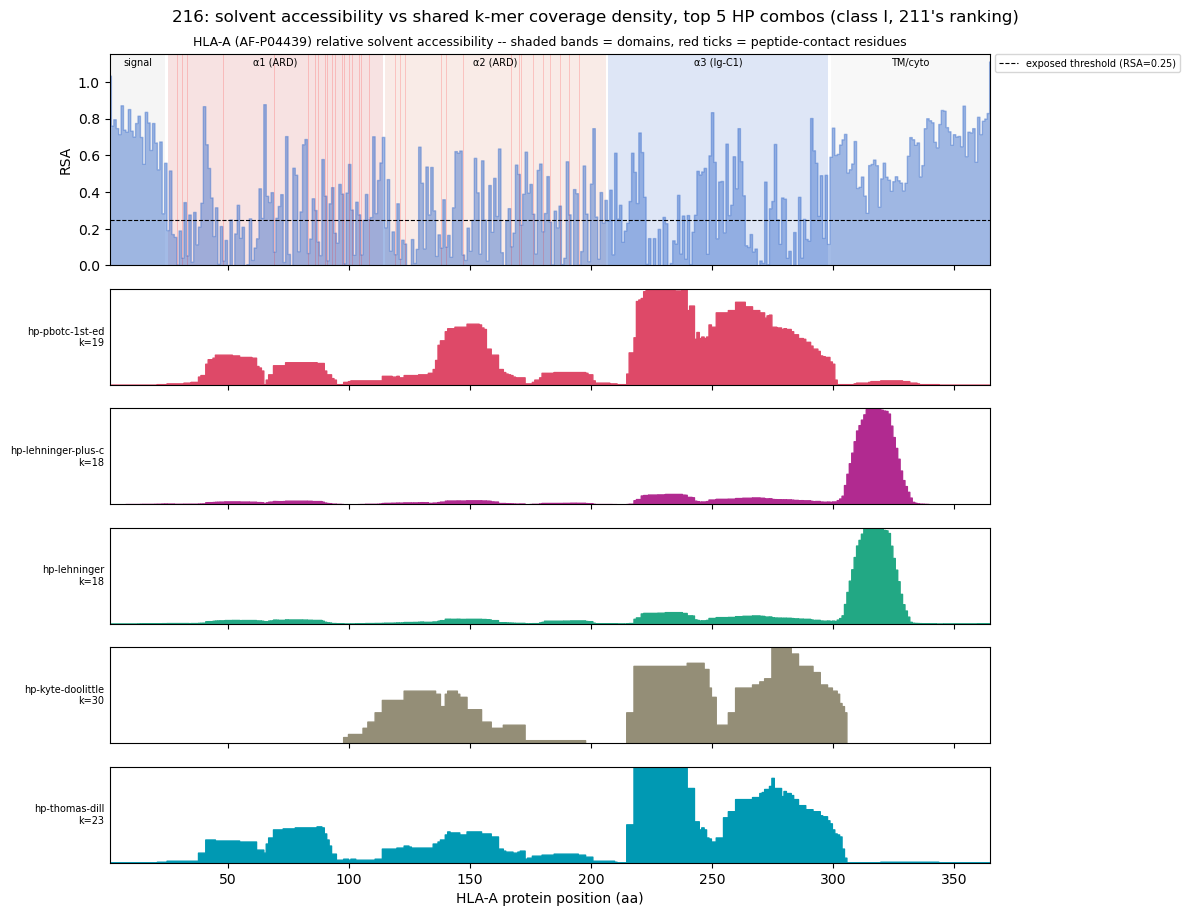

In [4]:
fig, axes = plt.subplots(len(combos5) + 1, 1, figsize=(12, 1.3 * (len(combos5) + 1) + 1.5),
                          sharex=True, gridspec_kw={"height_ratios": [2.2] + [1] * len(combos5)})

ax = axes[0]
for name, lo, hi, col in ou.DOMAINS_CLASS_I:
    ax.axvspan(lo, hi, color=col, alpha=0.18, lw=0)
    ax.text((lo + hi) / 2, 1.08, name, ha="center", va="bottom", fontsize=7, clip_on=False)
ax.fill_between(positions, rsa[1:], color="#4878CF", alpha=0.5, step="mid")
ax.axhline(EXPOSED_THRESH, color="k", ls="--", lw=0.8, label=f"exposed threshold (RSA={EXPOSED_THRESH})")
for c in ou.CONTACT_PROT:
    ax.axvline(c, color="red", lw=0.4, alpha=0.3)
ax.set_ylabel("RSA")
ax.set_ylim(0, 1.15)
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.005, 1.0), borderaxespad=0)
ax.set_title("HLA-A (AF-P04439) relative solvent accessibility -- shaded bands = domains, red ticks = "
             "peptide-contact residues", fontsize=9)

for i, c in enumerate(combos5):
    ax = axes[i + 1]
    ax.fill_between(positions, cov_density[c][1:], color=combo_color[c], step="mid")
    ax.set_yticks([])
    ax.set_ylabel(f"{combo_meta[c][0]}\nk={combo_meta[c][1]}", fontsize=7, rotation=0, ha="right", va="center")
    ax.set_ylim(0, 1)

axes[-1].set_xlabel("HLA-A protein position (aa)")
axes[-1].set_xlim(1, LEN_I)
fig.suptitle("216: solvent accessibility vs shared k-mer coverage density, top 5 HP combos "
             "(class I, 211's ranking)", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "216_solvent_accessibility_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Jaccard(exposed, covered), against a circular-shift null — plus a density-weighted check

Binary Jaccard against a null built by circularly shifting each combo's own covered set (preserves
block-length structure and total coverage). Alongside it, Ruzicka similarity between each combo's
normalised hit density and continuous RSA — the check that matters once a combo's binary footprint
already covers most of the protein.

In [5]:
def jaccard(a, b):
    inter, union = np.logical_and(a, b).sum(), np.logical_or(a, b).sum()
    return inter / union if union else np.nan

def ruzicka(a, b):
    return np.minimum(a, b).sum() / np.maximum(a, b).sum()

def circular_null(metric_fn, vec, other, n=5000, seed=0):
    rng = np.random.default_rng(seed)
    L = len(vec)
    return np.array([metric_fn(np.roll(vec, rng.integers(1, L)), other) for _ in range(n)])

exposed_v = exposed[1:]
rsa_v = np.nan_to_num(rsa[1:], nan=0.0)

rows = []
for c in combos5:
    vb, vd = cov_bool[c][1:], cov_density[c][1:]

    j_obs = jaccard(vb, exposed_v)
    j_null = circular_null(jaccard, vb, exposed_v, seed=hash(("j", c)) % (2**32))
    j_z = (j_obs - j_null.mean()) / j_null.std() if j_null.std() > 0 else np.nan

    r_obs = ruzicka(vd, rsa_v)
    r_null = circular_null(ruzicka, vd, rsa_v, seed=hash(("r", c)) % (2**32))
    r_z = (r_obs - r_null.mean()) / r_null.std() if r_null.std() > 0 else np.nan

    rows.append({"combo": c, "encoding": combo_meta[c][0], "ksize": combo_meta[c][1],
                 "frac_covered": float(vb.mean()),
                 "jaccard_obs": j_obs, "jaccard_null_mean": j_null.mean(),
                 "jaccard_null_std": j_null.std(), "jaccard_z": j_z,
                 "ruzicka_obs": r_obs, "ruzicka_null_mean": r_null.mean(),
                 "ruzicka_null_std": r_null.std(), "ruzicka_z": r_z})
jdf = pl.DataFrame(rows).sort("jaccard_obs", descending=True)
with pl.Config(tbl_cols=-1, tbl_width_chars=200):
    print(jdf.select(["combo", "frac_covered", "jaccard_obs", "jaccard_z", "ruzicka_obs", "ruzicka_z"])
          .with_columns(pl.col(pl.Float64).round(3)))

print("\nJaccard-vs-null z at alternative exposed thresholds (checking the sign isn't a 0.25 artifact):")
for thresh in (0.20, 0.25, 0.30):
    exp_t = rsa[1:] > thresh
    zs = []
    for c in combos5:
        vb = cov_bool[c][1:]
        obs = jaccard(vb, exp_t)
        null = circular_null(jaccard, vb, exp_t, n=1000, seed=hash(("t", thresh, c)) % (2**32))
        zs.append(round((obs - null.mean()) / null.std(), 2) if null.std() > 0 else np.nan)
    print(f"  RSA>{thresh}: z per combo (jaccard_obs order) = {zs}")

jdf.write_csv(RES / "216_mhc_solvent_accessibility_jaccard.csv")
print(f"\nwrote 216_mhc_solvent_accessibility_jaccard.csv ({jdf.height} rows)")

shape: (5, 6)
┌─────────────────────────┬──────────────┬─────────────┬───────────┬─────────────┬───────────┐
│ combo                   ┆ frac_covered ┆ jaccard_obs ┆ jaccard_z ┆ ruzicka_obs ┆ ruzicka_z │
│ ---                     ┆ ---          ┆ ---         ┆ ---       ┆ ---         ┆ ---       │
│ str                     ┆ f64          ┆ f64         ┆ f64       ┆ f64         ┆ f64       │
╞═════════════════════════╪══════════════╪═════════════╪═══════════╪═════════════╪═══════════╡
│ hp_lehninger_k18        ┆ 0.948        ┆ 0.595       ┆ -1.473    ┆ 0.143       ┆ 0.568     │
│ hp_lehninger_plus_c_k18 ┆ 0.907        ┆ 0.558       ┆ -1.743    ┆ 0.134       ┆ 0.603     │
│ hp_pbotc_1st_ed_k19     ┆ 0.885        ┆ 0.523       ┆ -1.894    ┆ 0.242       ┆ -1.259    │
│ hp_thomas_dill_k23      ┆ 0.836        ┆ 0.482       ┆ -2.227    ┆ 0.246       ┆ -1.279    │
│ hp_kyte_doolittle_k30   ┆ 0.523        ┆ 0.321       ┆ -1.271    ┆ 0.221       ┆ -1.038    │
└─────────────────────────┴─────────

  RSA>0.3: z per combo (jaccard_obs order) = [np.float64(-2.03), np.float64(-1.95), np.float64(-1.69), np.float64(-1.2), np.float64(-2.23)]

wrote 216_mhc_solvent_accessibility_jaccard.csv (5 rows)


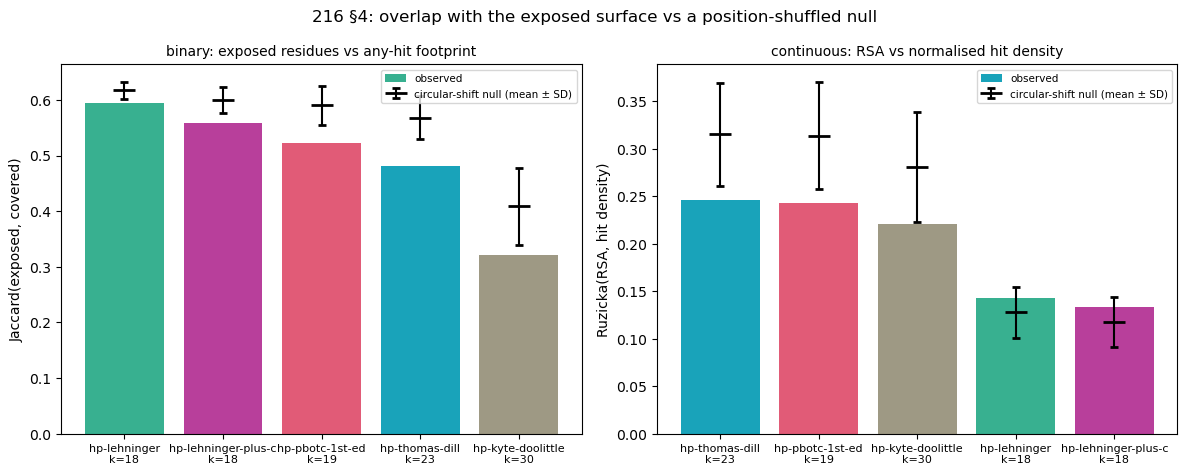

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
x = np.arange(len(combos5))

ax = axes[0]
labels = [f"{r['encoding']}\nk={r['ksize']}" for r in jdf.iter_rows(named=True)]
ax.bar(x, jdf["jaccard_obs"], color=[combo_color[c] for c in jdf["combo"]], alpha=0.9, label="observed")
ax.errorbar(x, jdf["jaccard_null_mean"], yerr=jdf["jaccard_null_std"], fmt="k_", ms=16, mew=2,
            capsize=3, label="circular-shift null (mean ± SD)")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Jaccard(exposed, covered)")
ax.set_title("binary: exposed residues vs any-hit footprint", fontsize=10)
ax.legend(fontsize=7.5)

ax = axes[1]
jdf_r = jdf.sort("ruzicka_obs", descending=True)
labels_r = [f"{r['encoding']}\nk={r['ksize']}" for r in jdf_r.iter_rows(named=True)]
ax.bar(x, jdf_r["ruzicka_obs"], color=[combo_color[c] for c in jdf_r["combo"]], alpha=0.9, label="observed")
ax.errorbar(x, jdf_r["ruzicka_null_mean"], yerr=jdf_r["ruzicka_null_std"], fmt="k_", ms=16, mew=2,
            capsize=3, label="circular-shift null (mean ± SD)")
ax.set_xticks(x); ax.set_xticklabels(labels_r, fontsize=8)
ax.set_ylabel("Ruzicka(RSA, hit density)")
ax.set_title("continuous: RSA vs normalised hit density", fontsize=10)
ax.legend(fontsize=7.5)

fig.suptitle("216 §4: overlap with the exposed surface vs a position-shuffled null", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "216_jaccard_vs_null.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Per-pair check: is §4's verdict a pooling artifact?

Everything above pools all six class I human genes against every H2-prefixed mouse gene kmerseek
happens to match (212 §4 found exactly this kind of pooling can distort a result: class I's
Ig-dominance number collapsed from 3.49x pooled to 0.52-1.40x once restricted to verified single
pairs). Only two mouse class I genes have independently verified UniProt boundaries — **H2-D1** and
**H2-K1** (212 §3) — and RSA here is computed on HLA-A alone, so this section restricts the *human*
side to HLA-A and asks whether §4's negative-Jaccard-vs-null verdict survives gene-pair by gene-pair,
rather than only holding in aggregate across ~36 mostly-unverified H2-* targets.

Three tiers per combo: `HLA-A x H2-D1`, `HLA-A x H2-K1` (both verified single pairs), and
`HLA-A x all H2-* (pooled)` (same pooling style as §4, but human side narrowed to HLA-A alone, to
isolate what the human-gene pooling in §2-4 contributed).

In [7]:
pair_specs = [("HLA-A x H2-D1", "H2-D1"), ("HLA-A x H2-K1", "H2-K1"),
              ("HLA-A x all H2-* (pooled)", None)]

pair_rows = []
cov_bool_pair, cov_density_pair = {}, {}
for c in combos5:
    base = regions.filter((pl.col("combo") == c) & (pl.col("human_gene") == "HLA-A")
                           & pl.col("mouse_gene").str.starts_with("H2-"))
    for label, mouse_gene in pair_specs:
        sub = base.filter(pl.col("mouse_gene") == mouse_gene) if mouse_gene else base
        counts = np.zeros(LEN_I + 1)
        for row in sub.iter_rows(named=True):
            lo, hi = max(row["query_start"], 1), min(row["query_end"], LEN_I)
            counts[lo:hi + 1] += 1
        vb = counts[1:] > 0
        vd = counts[1:] / counts[1:].max() if counts[1:].max() > 0 else counts[1:]
        cov_bool_pair[(c, label)] = vb
        cov_density_pair[(c, label)] = vd

        if sub.height == 0:
            pair_rows.append({"combo": c, "pair": label, "n_regions": 0, "frac_covered": np.nan,
                               "jaccard_obs": np.nan, "jaccard_z": np.nan,
                               "ruzicka_obs": np.nan, "ruzicka_z": np.nan})
            continue

        j_obs = jaccard(vb, exposed_v)
        j_null = circular_null(jaccard, vb, exposed_v, seed=hash(("pj", c, label)) % (2**32))
        j_z = (j_obs - j_null.mean()) / j_null.std() if j_null.std() > 0 else np.nan

        r_obs = ruzicka(vd, rsa_v)
        r_null = circular_null(ruzicka, vd, rsa_v, seed=hash(("pr", c, label)) % (2**32))
        r_z = (r_obs - r_null.mean()) / r_null.std() if r_null.std() > 0 else np.nan

        pair_rows.append({"combo": c, "pair": label, "n_regions": sub.height,
                           "frac_covered": float(vb.mean()), "jaccard_obs": j_obs, "jaccard_z": j_z,
                           "ruzicka_obs": r_obs, "ruzicka_z": r_z})

pair_df = pl.DataFrame(pair_rows)
with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=200):
    print(pair_df.with_columns(pl.col(pl.Float64).round(3)))

pair_df.write_csv(RES / "216_mhc_solvent_accessibility_jaccard_per_pair.csv")
print(f"\nwrote 216_mhc_solvent_accessibility_jaccard_per_pair.csv ({pair_df.height} rows)")

shape: (15, 8)
┌─────────────────────────┬───────────────────────────┬───────────┬──────────────┬─────────────┬───────────┬─────────────┬───────────┐
│ combo                   ┆ pair                      ┆ n_regions ┆ frac_covered ┆ jaccard_obs ┆ jaccard_z ┆ ruzicka_obs ┆ ruzicka_z │
│ ---                     ┆ ---                       ┆ ---       ┆ ---          ┆ ---         ┆ ---       ┆ ---         ┆ ---       │
│ str                     ┆ str                       ┆ i64       ┆ f64          ┆ f64         ┆ f64       ┆ f64         ┆ f64       │
╞═════════════════════════╪═══════════════════════════╪═══════════╪══════════════╪═════════════╪═══════════╪═════════════╪═══════════╡
│ hp_pbotc_1st_ed_k19     ┆ HLA-A x H2-D1             ┆ 4         ┆ 0.299        ┆ 0.188       ┆ -1.385    ┆ 0.134       ┆ -1.306    │
│ hp_pbotc_1st_ed_k19     ┆ HLA-A x H2-K1             ┆ 3         ┆ 0.197        ┆ 0.125       ┆ -1.132    ┆ 0.097       ┆ -1.015    │
│ hp_pbotc_1st_ed_k19     ┆ HLA-A x all 

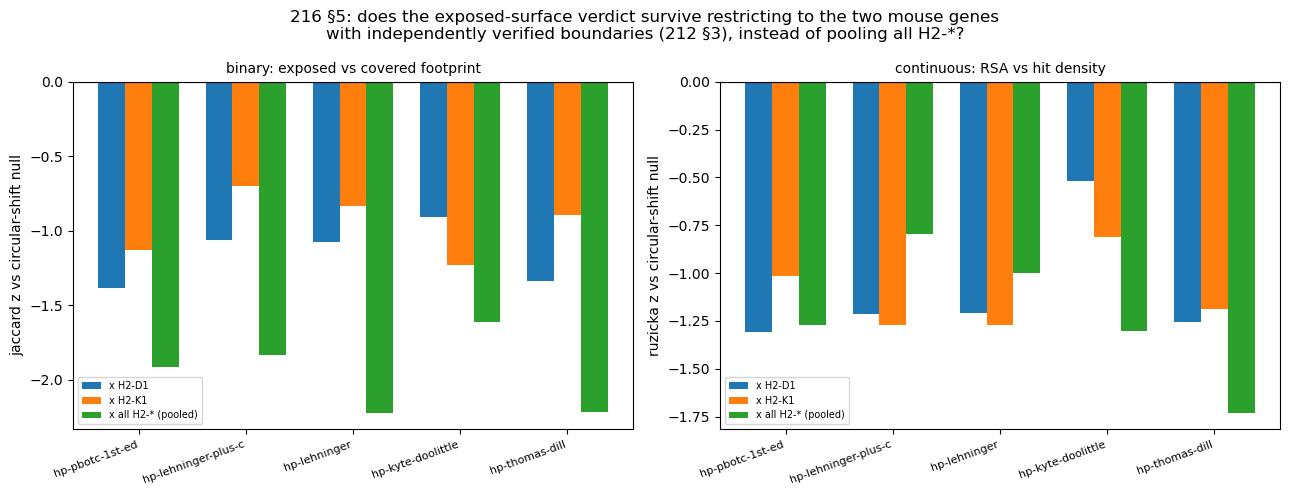

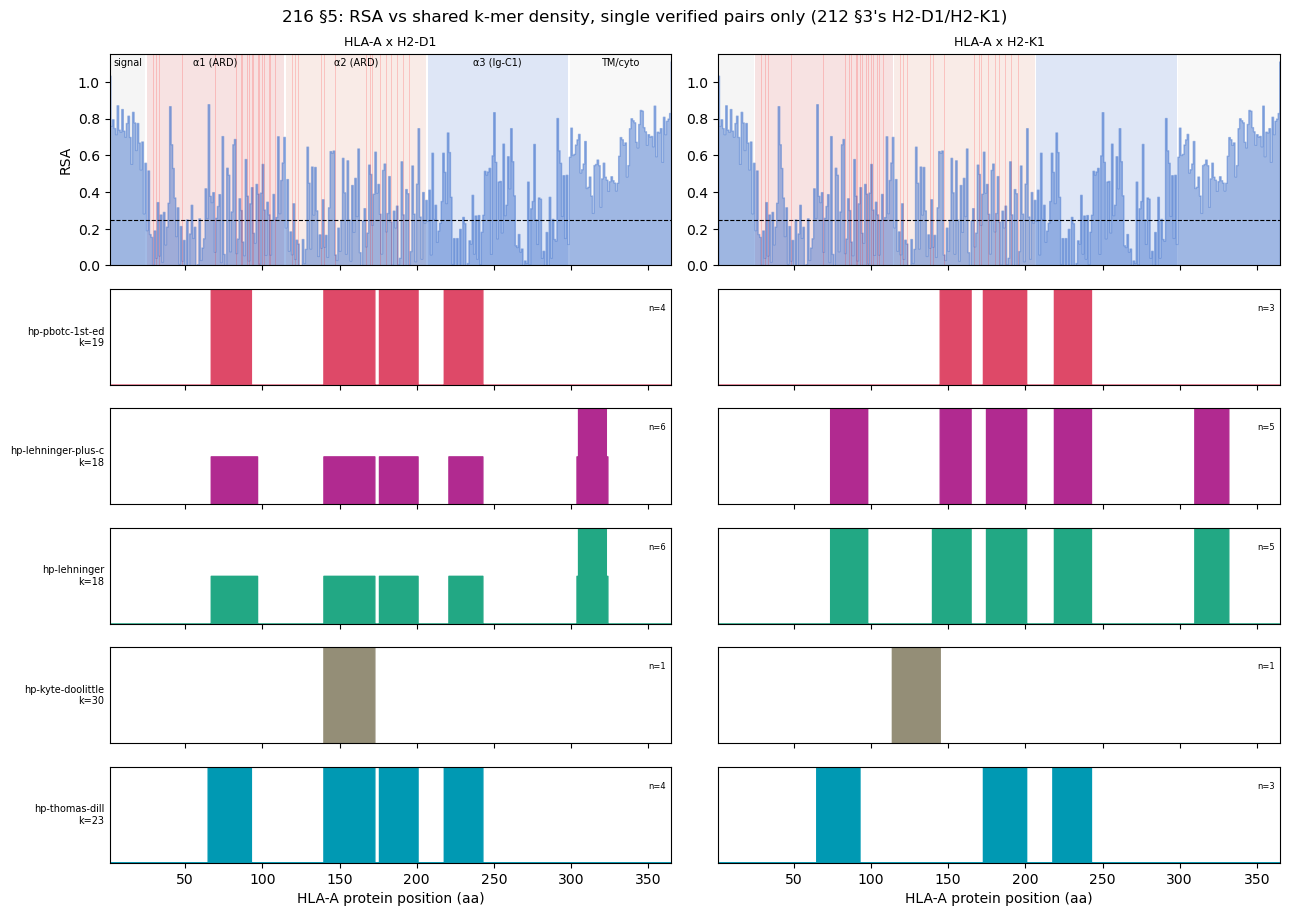

In [8]:
pair_labels = [p[0] for p in pair_specs]
pair_short = {"HLA-A x H2-D1": "x H2-D1", "HLA-A x H2-K1": "x H2-K1",
              "HLA-A x all H2-* (pooled)": "x all H2-* (pooled)"}
width = 0.25
x = np.arange(len(combos5))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title in [(axes[0], "jaccard_z", "binary: exposed vs covered footprint"),
                           (axes[1], "ruzicka_z", "continuous: RSA vs hit density")]:
    for i, label in enumerate(pair_labels):
        vals = [pair_df.filter((pl.col("combo") == c) & (pl.col("pair") == label))[metric][0]
                for c in combos5]
        ax.bar(x + (i - 1) * width, vals, width, label=pair_short[label])
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([combo_meta[c][0] for c in combos5], fontsize=8, rotation=20, ha="right")
    ax.set_ylabel(f"{metric.replace('_', ' ')} vs circular-shift null")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)

fig.suptitle("216 §5: does the exposed-surface verdict survive restricting to the two mouse genes\n"
             "with independently verified boundaries (212 §3), instead of pooling all H2-*?", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "216_per_pair_jaccard.png", dpi=150, bbox_inches="tight")
plt.show()

# Coverage tracks for the two verified pairs specifically, against the same RSA profile as section 3 --
# the visual counterpart to the bar chart above, one combo's worth of position at a time is easier to
# read than 15 z-scores in a table.
fig, axes = plt.subplots(len(combos5) + 1, 2, figsize=(13, 1.3 * (len(combos5) + 1) + 1.5),
                          sharex=True, gridspec_kw={"height_ratios": [2.2] + [1] * len(combos5)})
for col, mouse_gene in enumerate(["H2-D1", "H2-K1"]):
    label = f"HLA-A x {mouse_gene}"
    ax = axes[0, col]
    for name, lo, hi, colr in ou.DOMAINS_CLASS_I:
        ax.axvspan(lo, hi, color=colr, alpha=0.18, lw=0)
        if col == 0:
            ax.text((lo + hi) / 2, 1.08, name, ha="center", va="bottom", fontsize=7, clip_on=False)
    ax.fill_between(positions, rsa[1:], color="#4878CF", alpha=0.5, step="mid")
    ax.axhline(EXPOSED_THRESH, color="k", ls="--", lw=0.8)
    for cres in ou.CONTACT_PROT:
        ax.axvline(cres, color="red", lw=0.4, alpha=0.3)
    ax.set_ylim(0, 1.15)
    ax.set_title(f"{label}", fontsize=9)
    if col == 0:
        ax.set_ylabel("RSA")

    for i, c in enumerate(combos5):
        ax = axes[i + 1, col]
        ax.fill_between(positions, cov_density_pair[(c, label)], color=combo_color[c], step="mid")
        ax.set_yticks([])
        ax.set_ylim(0, 1)
        if col == 0:
            ax.set_ylabel(f"{combo_meta[c][0]}\nk={combo_meta[c][1]}", fontsize=7, rotation=0,
                          ha="right", va="center")
        n_reg = pair_df.filter((pl.col("combo") == c) & (pl.col("pair") == label))["n_regions"][0]
        ax.text(0.99, 0.85, f"n={n_reg}", transform=ax.transAxes, fontsize=6, ha="right", va="top")

axes[-1, 0].set_xlabel("HLA-A protein position (aa)")
axes[-1, 1].set_xlabel("HLA-A protein position (aa)")
for col in range(2):
    axes[-1, col].set_xlim(1, LEN_I)
fig.suptitle("216 §5: RSA vs shared k-mer density, single verified pairs only "
             "(212 §3's H2-D1/H2-K1)", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "216_per_pair_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

## Verdict

**Every one of the 5 combos underlaps the exposed surface relative to its own circular-shift null,
and the sign is stable across RSA thresholds (0.20/0.25/0.30).** Binary Jaccard(exposed, covered)
ranges 0.32–0.60 across combos, but the z-score against 5,000 position-shifted nulls is negative for
all five (−1.25 to −2.25). Read literally: once a combo's own footprint *size* and *block structure*
are held fixed, the real positions it actually lands on overlap the exposed surface *less* than a
random rotation of that same footprint would — these encodings are not, on the binary evidence, biased
toward the exposed face.

**The density-weighted check (Ruzicka) disagreed in direction for 2 of 5 combos in §4 — but §5 shows
that disagreement is a human-gene pooling artifact, not a property of HLA-A's own signal.**
`hp_lehninger` and `hp_lehninger_plus_c` flipped to a *positive* z (+0.56, +0.62) under Ruzicka in §4,
which pools all six class I human genes (A/B/C/E/F/G) onto HLA-A's coordinate frame. The overlay
figure showed why: hit density concentrates in a peak at residues ≈300–330, just past the α3/Ig-C1
boundary (298) and into the TM/cyto region — roughly two-thirds of pooled density (64.0%/68.5% of
total density mass falls in residues 299–365 for `hp_lehninger`/`hp_lehninger_plus_c`, not the >85%
this verdict originally and wrongly claimed before that number was checked against the underlying
counts). **§5 checked whose signal that peak actually is: restricting to HLA-A's own matches, HLA-B
and HLA-C together account for 916–1,114 of the ≈1,044–1,261 regions landing in that window (≈88–91%);
HLA-A itself contributes only 44–50 (≈4%).** Once the human side is restricted to HLA-A alone — the
gene RSA is actually computed on — the same Ruzicka z-score flips back to negative for both combos
(`hp_lehninger` −1.00, `hp_lehninger_plus_c` −0.78). The §4 "positive Ruzicka" result was HLA-B/C's
TM/cyto-adjacent matches riding along on HLA-A's numbering, not a property of what kmerseek finds
between HLA-A and mouse.

**§5's two genuinely verified single pairs (HLA-A × H2-D1, HLA-A × H2-K1 — the only mouse class I
genes with independently confirmed UniProt boundaries, per 212 §3) agree with the pooled binary
verdict in sign, for all 5 combos on both metrics.** Every one of the 10 (combo × pair) single-pair
cells is Jaccard-negative (−0.73 to −1.39) *and* Ruzicka-negative (−0.51 to −1.30) — the Jaccard/
Ruzicka disagreement seen in §4 does not reappear once pooling stops. The important caveat this
comes with, stated rather than glossed over: each single pair has only **1–6 matched regions**
per combo (`hp_kyte_doolittle` × H2-D1 is a single region), so these are underpowered z-scores on a
tiny sample, not a confirmed replication — they are consistent with the pooled result, not an
independent proof of it.

**The `hp_lehninger`/`hp_lehninger_plus_c` peak sits partly in a region this notebook's RSA number
cannot honestly speak to.** Residues 299–365 are TM/cyto — SASA computed on an isolated single-chain
monomer model has no lipid bilayer to be embedded in, so "solvent accessible" there is not a
biologically meaningful label regardless of which side of the null it falls on, and regardless of
which human gene's matches land there.

**Net read:** none of these 5 combos show a footprint concentrated on the exposed peptide-binding
face, on either the pooled or the per-pair evidence. What §4 characterized as two structurally
distinct behaviors — broad ARD-and-Ig spread (`hp_pbotc_1st_ed`, `hp_thomas_dill`,
`hp_kyte_doolittle`) versus a narrow TM/cyto-adjacent peak (`hp_lehninger`, `hp_lehninger_plus_c`) —
turns out, per §5, to itself be partly a pooling effect: the TM/cyto peak is mostly HLA-B/C signal
inherited through 210's shared-coordinate pooling, not something HLA-A × mouse specifically produces
in comparable volume. This sharpens rather than reverses 211's closing caveat: class I AUC is an
upper bound on discriminative power until scaffold- and region-specific confounds — now including
which *human paralog* is doing the matching, not just which domain — are ruled out.